## Data Description
<center>

| Records | Features |
| :-- | :-- |
| 5700 | 21 |


| Id | Features | Description |
| :-- | :--| :--|
|01| **state** | 2-letter code of the US state of customer residence|
|02| **account_length** | Number of months the customer has been with the current telco provider |
|03|**area_code**|string="area_code_AAA" where AAA = 3 digit area code|
|04|**intl_plan**|The customer has international plan|
|05|**vmail_plan**| The customer has voice mail plan|
|06|**vmail_messages**|Number of voice-mail messages|
|07|**day_mins**|Total minutes of day calls|
|08|**day_calls**|Total no of day calls|
|09|**day_charge**|Total charge of day calls|
|10|**eve_mins**|Total minutes of evening calls|
|11|**eve_calls**|Total no of evening calls|
|12|**eve_charge**|Total charge of evening calls|
|13|**night_mins**|Total minutes of night calls|
|14|**night_calls**|Total no of night calls|
|15|**night_charge**|Total charge of night calls|
|16|**intl_mins**|Total minutes of international calls|
|17|**intl_calls**|Total no of international calls|
|18|**intl_charge**|Total charge of international calls|
|19|**customer_service_calls**|Number of calls to customer service|
|20|**phone**|10 digit number|
|21|**churn**|Customer churn - target variable|

In [1]:
#Churn prediction in telecom.
import numpy as np
import matplotlib.pyplot as plt

In [2]:
!gdown 1uUt7uL-VuF_5cpodYRiriEwhsldeEp3m

Downloading...
From: https://drive.google.com/uc?id=1uUt7uL-VuF_5cpodYRiriEwhsldeEp3m
To: /content/churn_logistic.csv
100% 494k/494k [00:00<00:00, 106MB/s]


In [3]:
import pandas as pd
churn = pd.read_csv("churn_logistic.csv")
churn.head()

,Account Length,VMail Message,Day Mins,Eve Mins,Night Mins,Intl Mins,CustServ Calls,Intl Plan,VMail Plan,Day Calls,...,Eve Calls,Eve Charge,Night Calls,Night Charge,Intl Calls,Intl Charge,State,Area Code,Phone,Churn
0,128,25,265.1,197.4,244.7,10.0,1,0,1,110,...,99,16.78,91,11.01,3,2.70,KS,415,382-4657,0
1,107,26,161.6,195.5,254.4,13.7,1,0,1,123,...,103,16.62,103,11.45,3,3.70,OH,415,371-7191,0
2,137,0,243.4,121.2,162.6,12.2,0,0,0,114,...,110,10.30,104,7.32,5,3.29,NJ,415,358-1921,0
3,84,0,299.4,61.9,196.9,6.6,2,1,0,71,...,88,5.26,89,8.86,7,1.78,OH,408,375-9999,0
4,75,0,166.7,148.3,186.9,10.1,3,1,0,113,...,122,12.61,121,8.41,3,2.73,OK,415,330-6626,0


## Logistic Regression Intuition

**Left Side**
- We know that in linear regression we try to fit a line or a plane to most of the points and then using the line predict values for future values.
- We have Linear Regression plot which we know when we predicted **price of car** using its **age**.
- This plot looks like a good fit,right?

**Right side**
- Now the **problem** has changed, you want to identify the classes
- We have data points for two classes, class1 and class2
  - Here class 1 or dot means churned and class 2 or cross means not churned.

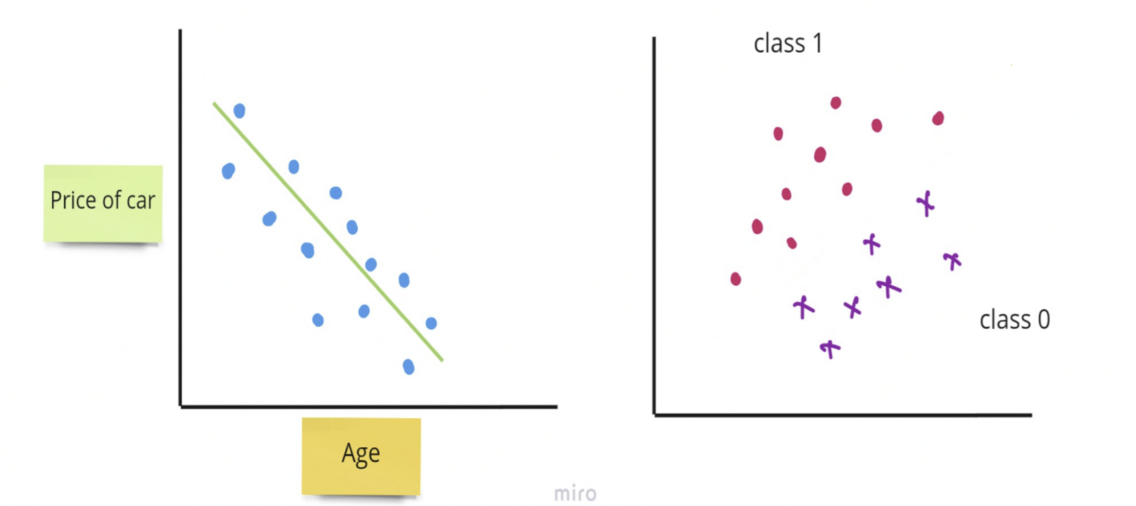


- What we want now is the line that separates our class 1 points from class 0 points.

- The idea here is that we want a line or a plane such that points are on the either side of line/plane.

- we can get that hyperplane as $ z= w_0 + w_1x_1 + w_2x_2 + ....... +w_dx_d $


  <center><img src="https://drive.google.com/uc?id=1EsD_N1XSR8Plze05K3bufoU5aGWjLVTj" width="400" height="300"> </center>

- You could also check plane how it separates in 3D.
                                     

## Sigmoid - Logistic : This is a function

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import math

In [5]:
def sigmoid(x):
    return 1/(1+np.e**-x)

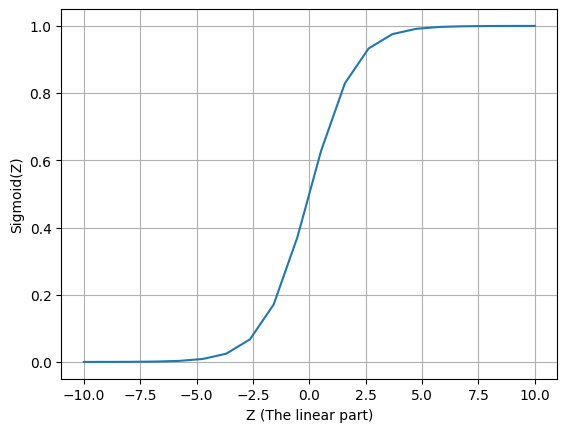

In [12]:
x = np.linspace(-10, 10, 20) # 20 equidistant points between -10 and 10
z = sigmoid(x)

plt.plot(x, z)
plt.xlabel("Z (The linear part)")
plt.ylabel("Sigmoid(Z)")
plt.grid()
plt.show()

## Loss function

In [9]:
def loss(y,yhat):
  return -y*math.log(yhat)-(1-y)*math.log(1-yhat)

In [11]:
# y = 0 or 1

In [13]:
#yhat = 0 to 1

In [14]:
y = 1
yhat = 0.99

loss(y,yhat)

0.01005033585350145

In [15]:
y=1
yhat=0.01

In [16]:
loss(y,yhat)

4.605170185988091

In [17]:
y=0
yhat1=0.00001111
yhat2 = 0.9999999

In [18]:
loss(y,yhat1)

1.111006171648797e-05

In [20]:
loss(y,yhat2)/loss(y,yhat1)

1450765.6269419724

In [21]:
def mse(y, yhat):
    return (y - yhat) ** 2

In [22]:
y=0
yhat1=0.00001111
yhat2 = 0.9999999

In [23]:
mse(y, yhat1)

1.234321e-10

In [24]:
mse(y, yhat2)

0.9999998000000101

## We dont use MSE loss function -- Because when MSE + Sigmoid - Your curve becomes non convex

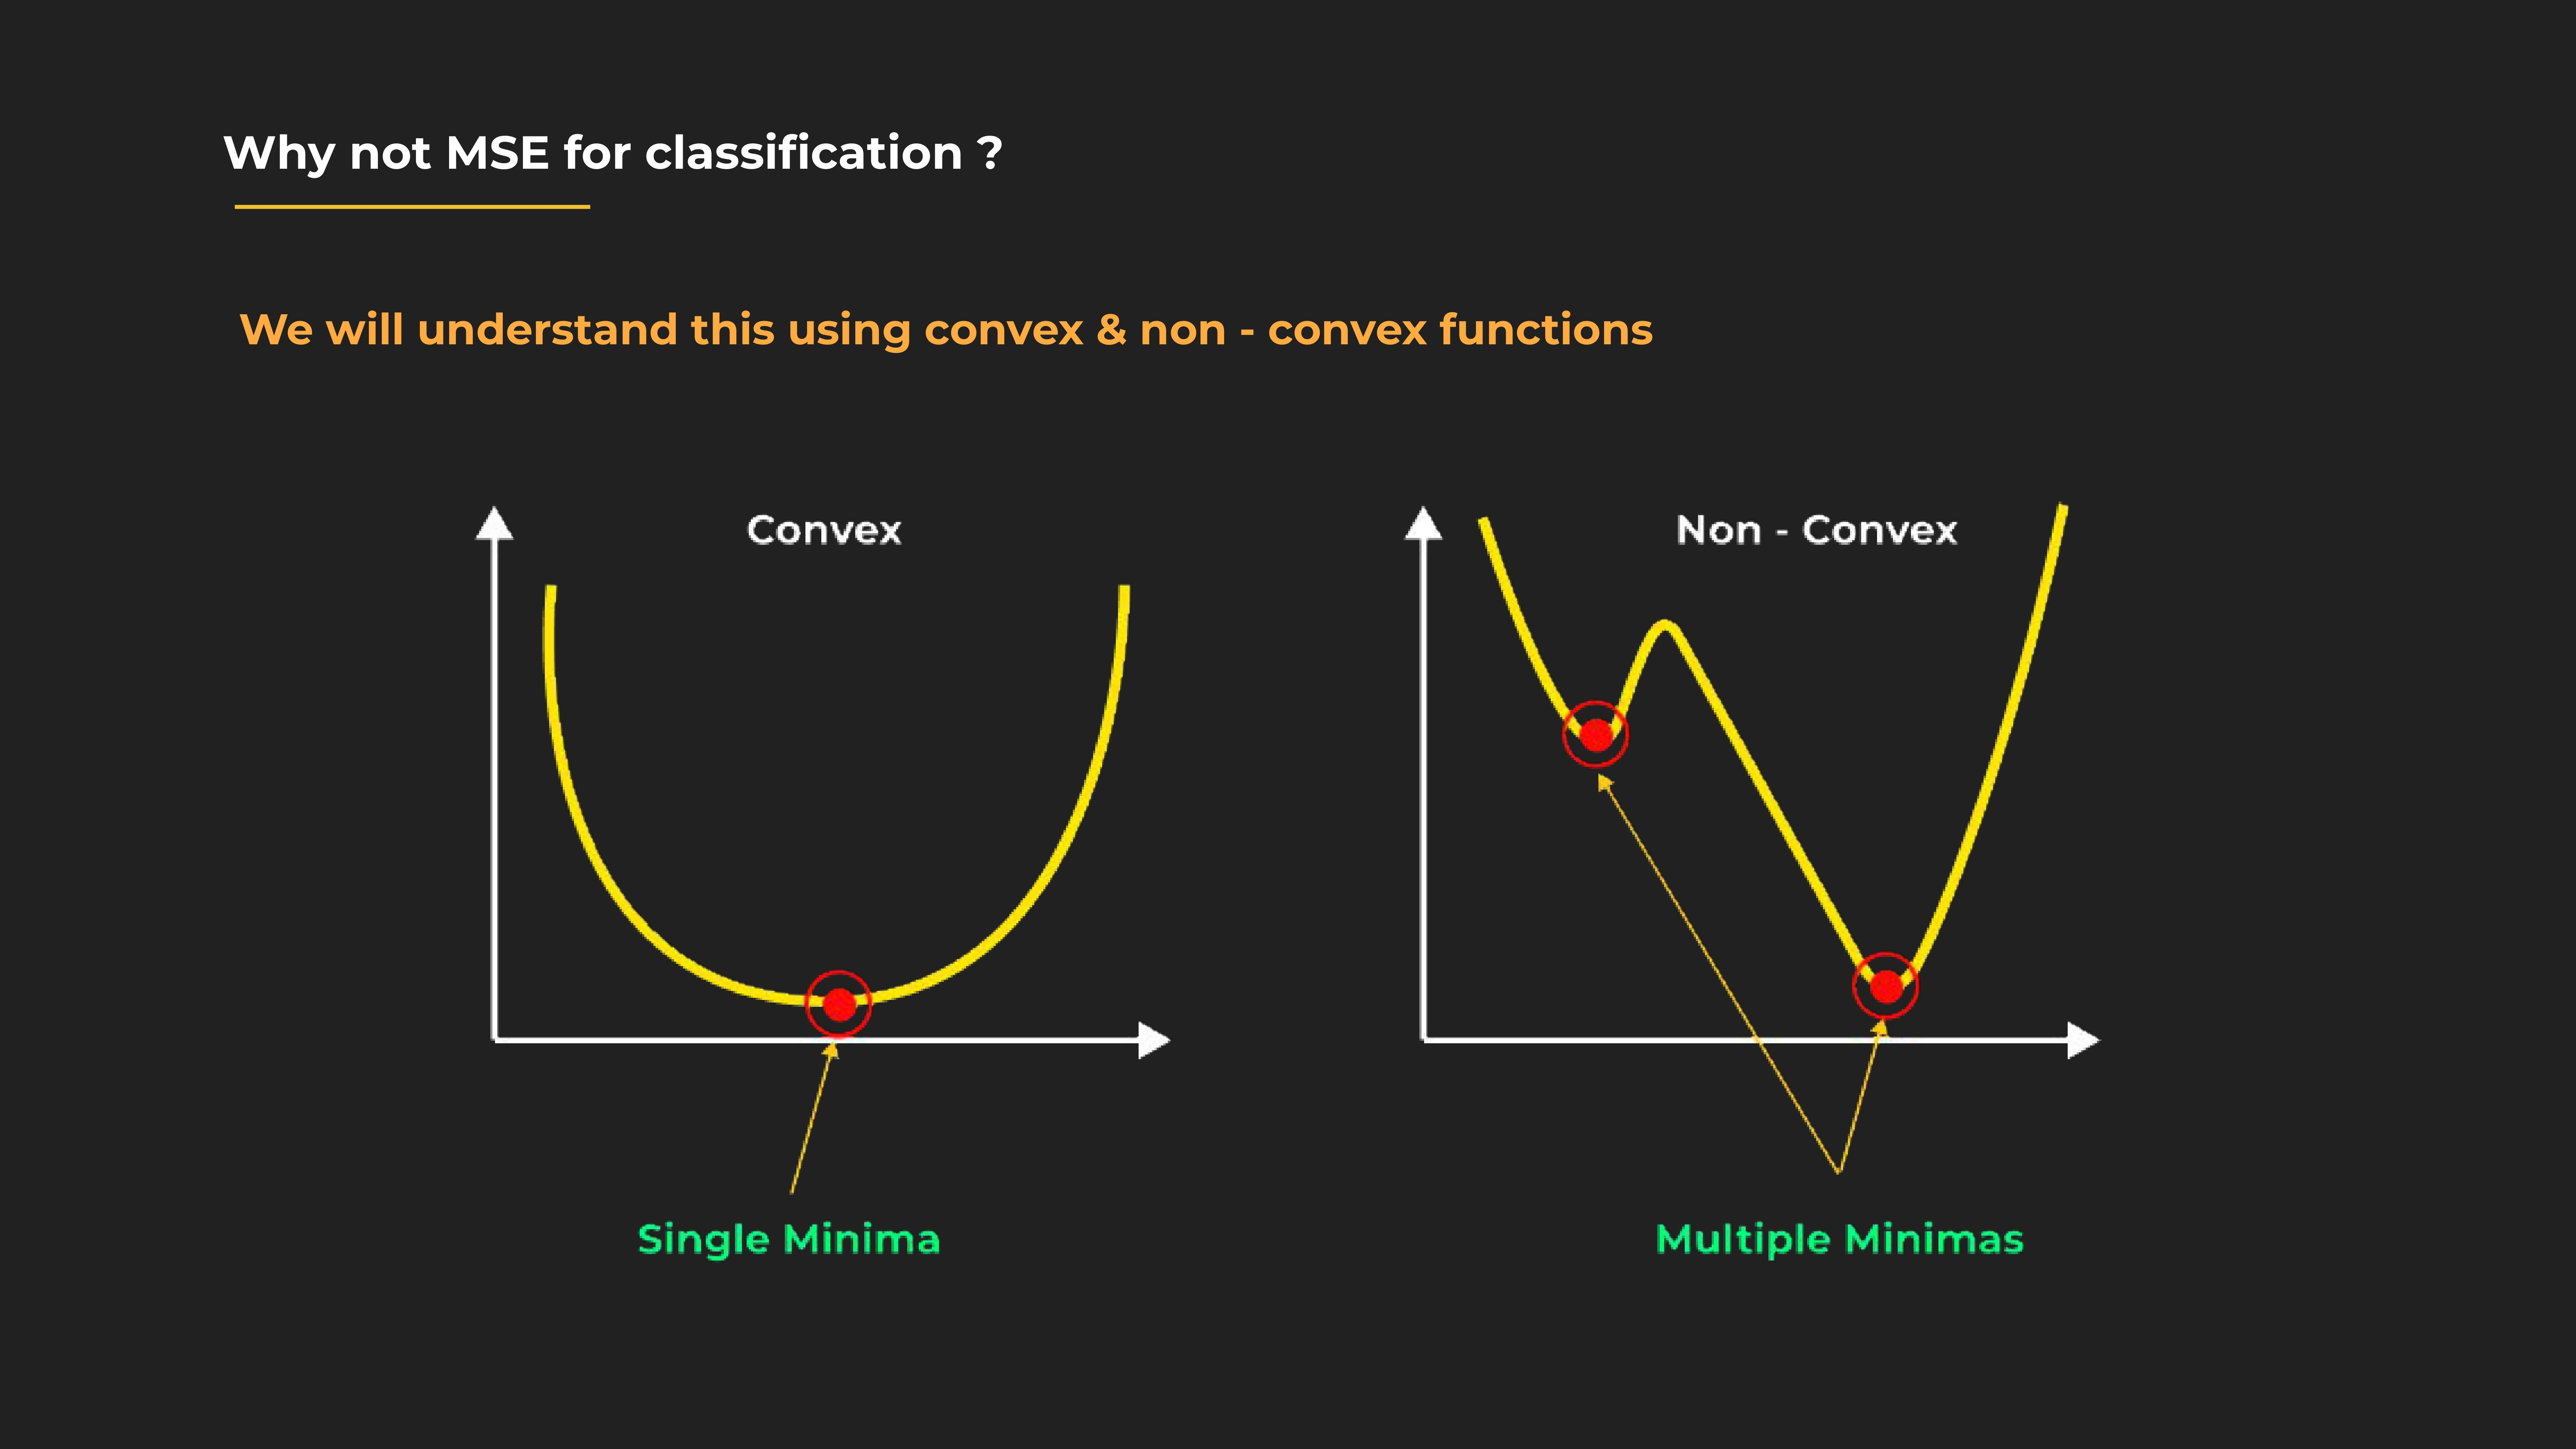

In [25]:
#Churn prediction in telecom.
import numpy as np
import matplotlib.pyplot as plt

In [26]:
!gdown 1uUt7uL-VuF_5cpodYRiriEwhsldeEp3m

Downloading...
From: https://drive.google.com/uc?id=1uUt7uL-VuF_5cpodYRiriEwhsldeEp3m
To: /content/churn_logistic.csv
100% 494k/494k [00:00<00:00, 97.4MB/s]


In [27]:
import pandas as pd
churn = pd.read_csv("churn_logistic.csv")
churn.head()

,Account Length,VMail Message,Day Mins,Eve Mins,Night Mins,Intl Mins,CustServ Calls,Intl Plan,VMail Plan,Day Calls,...,Eve Calls,Eve Charge,Night Calls,Night Charge,Intl Calls,Intl Charge,State,Area Code,Phone,Churn
0,128,25,265.1,197.4,244.7,10.0,1,0,1,110,...,99,16.78,91,11.01,3,2.70,KS,415,382-4657,0
1,107,26,161.6,195.5,254.4,13.7,1,0,1,123,...,103,16.62,103,11.45,3,3.70,OH,415,371-7191,0
2,137,0,243.4,121.2,162.6,12.2,0,0,0,114,...,110,10.30,104,7.32,5,3.29,NJ,415,358-1921,0
3,84,0,299.4,61.9,196.9,6.6,2,1,0,71,...,88,5.26,89,8.86,7,1.78,OH,408,375-9999,0
4,75,0,166.7,148.3,186.9,10.1,3,1,0,113,...,122,12.61,121,8.41,3,2.73,OK,415,330-6626,0


<Axes: xlabel='Churn', ylabel='Day Mins'>

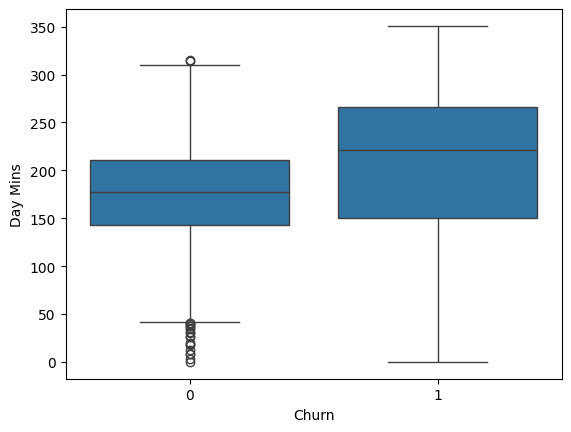

In [28]:
import seaborn as sns
sns.boxplot(x='Churn', y='Day Mins', data = churn)

<Axes: xlabel='Churn', ylabel='Account Length'>

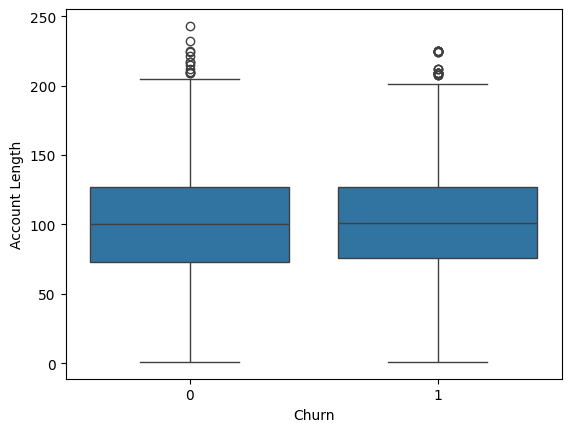

In [29]:
sns.boxplot(x = 'Churn', y= 'Account Length', data = churn)

## Model Feedback

In [30]:
cols = ['Day Mins', 'Eve Mins', 'CustServ Calls', 'Intl Plan','VMail Message'] ## free to use more columns
y = churn["Churn"]
X = churn[cols]
X.shape

(5700, 5)

In [31]:
y = churn["Churn"]
X = churn[cols]

In [32]:
X

,Day Mins,Eve Mins,CustServ Calls,Intl Plan,VMail Message
0,265.1,197.4,1,0,25
1,161.6,195.5,1,0,26
2,243.4,121.2,0,0,0
3,299.4,61.9,2,1,0
4,166.7,148.3,3,1,0
...,...,...,...,...,...
5695,171.5,160.0,1,1,0
5696,131.6,179.3,1,0,0
5697,291.2,234.2,1,0,0
5698,113.3,197.9,4,0,0


In [33]:
y

,Churn
0,0
1,0
2,0
3,0
4,0
...,...
5695,1
5696,1
5697,1
5698,1


In [35]:
from sklearn.model_selection import train_test_split

X_tr_cv, X_test, y_tr_cv, y_test = train_test_split(X, y, test_size=0.2, random_state=4)


X_train, X_val, y_train, y_val = train_test_split(X_tr_cv, y_tr_cv, test_size=0.25,random_state=4)
X_train.shape

(3420, 5)

In [36]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaler.fit(X_train)

X_train = scaler.transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

In [46]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression() ## C = 1
model.fit(X_train, y_train)

LogisticRegression()

In [38]:
model.coef_

array([[ 0.78674301,  0.31084942,  0.94070165,  0.86919545, -0.31809071]])

In [39]:
model.intercept_

array([0.05297365])

In [40]:
y_pred = model.predict(X_val)

In [41]:
print(y_pred)

[0 0 1 ... 0 0 0]


In [42]:
## Model is taking a default cut off of 0.5

# prob > 0.5 - model --- yhat = 1

## prob < 0.5 model --- yhat = 0

In [43]:
y_pred_prob = model.predict_proba(X_val)

In [44]:
y_pred_prob

array([[0.70985217, 0.29014783],
       [0.8681417 , 0.1318583 ],
       [0.45621812, 0.54378188],
       ...,
       [0.95273524, 0.04726476],
       [0.60128439, 0.39871561],
       [0.81202669, 0.18797331]])

In [45]:
print(f'Train Accuracy:{model.score(X_train,y_train)}, Val Accuracy:{model.score(X_val,y_val) }' )

Train Accuracy:0.7564327485380117, Val Accuracy:0.7578947368421053


## Regularisation in Log Reg

## 10:25 pm

## Hyperparameter Tune the Log Regh model

In [47]:
from sklearn.pipeline import make_pipeline
train_scores = []
val_scores = []
scaler = StandardScaler()

In [52]:
for la in np.arange(0.01, 12000.0, 100): # range of values of Lambda
  scaled_lr = make_pipeline( scaler, LogisticRegression(C=1/la))

  scaled_lr.fit(X_train, y_train)
  train_score = scaled_lr.score(X_train, y_train)
  val_score = scaled_lr.score(X_val, y_val)

  train_scores.append(train_score)
  val_scores.append(val_score)

In [53]:
len(val_scores)

120

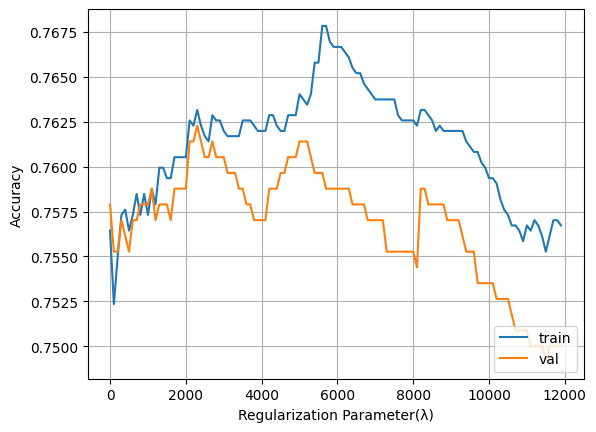

In [56]:
plt.figure()
plt.plot(list(np.arange(0.01, 12000.0, 100)), train_scores, label="train")
plt.plot(list(np.arange(0.01, 12000.0, 100)), val_scores, label="val")
plt.legend(loc='lower right')

plt.xlabel("Regularization Parameter(λ)")
plt.ylabel("Accuracy")
plt.grid()
plt.show()

In [63]:
max(val_scores)

0.762280701754386

In [57]:
np.argmax(val_scores)

np.int64(23)

In [58]:
val_scores[23]

0.762280701754386

In [59]:
l_best = 0.01 + 23 * 100
l_best

2300.01

In [60]:
scaled_lr = make_pipeline( scaler, LogisticRegression(C=1/l_best))
scaled_lr.fit(X_train, y_train)

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('logisticregression',
                 LogisticRegression(C=0.0004347807183447028))])

In [61]:
test_score = scaled_lr.score(X_test,y_test)
print(test_score)

0.7684210526315789


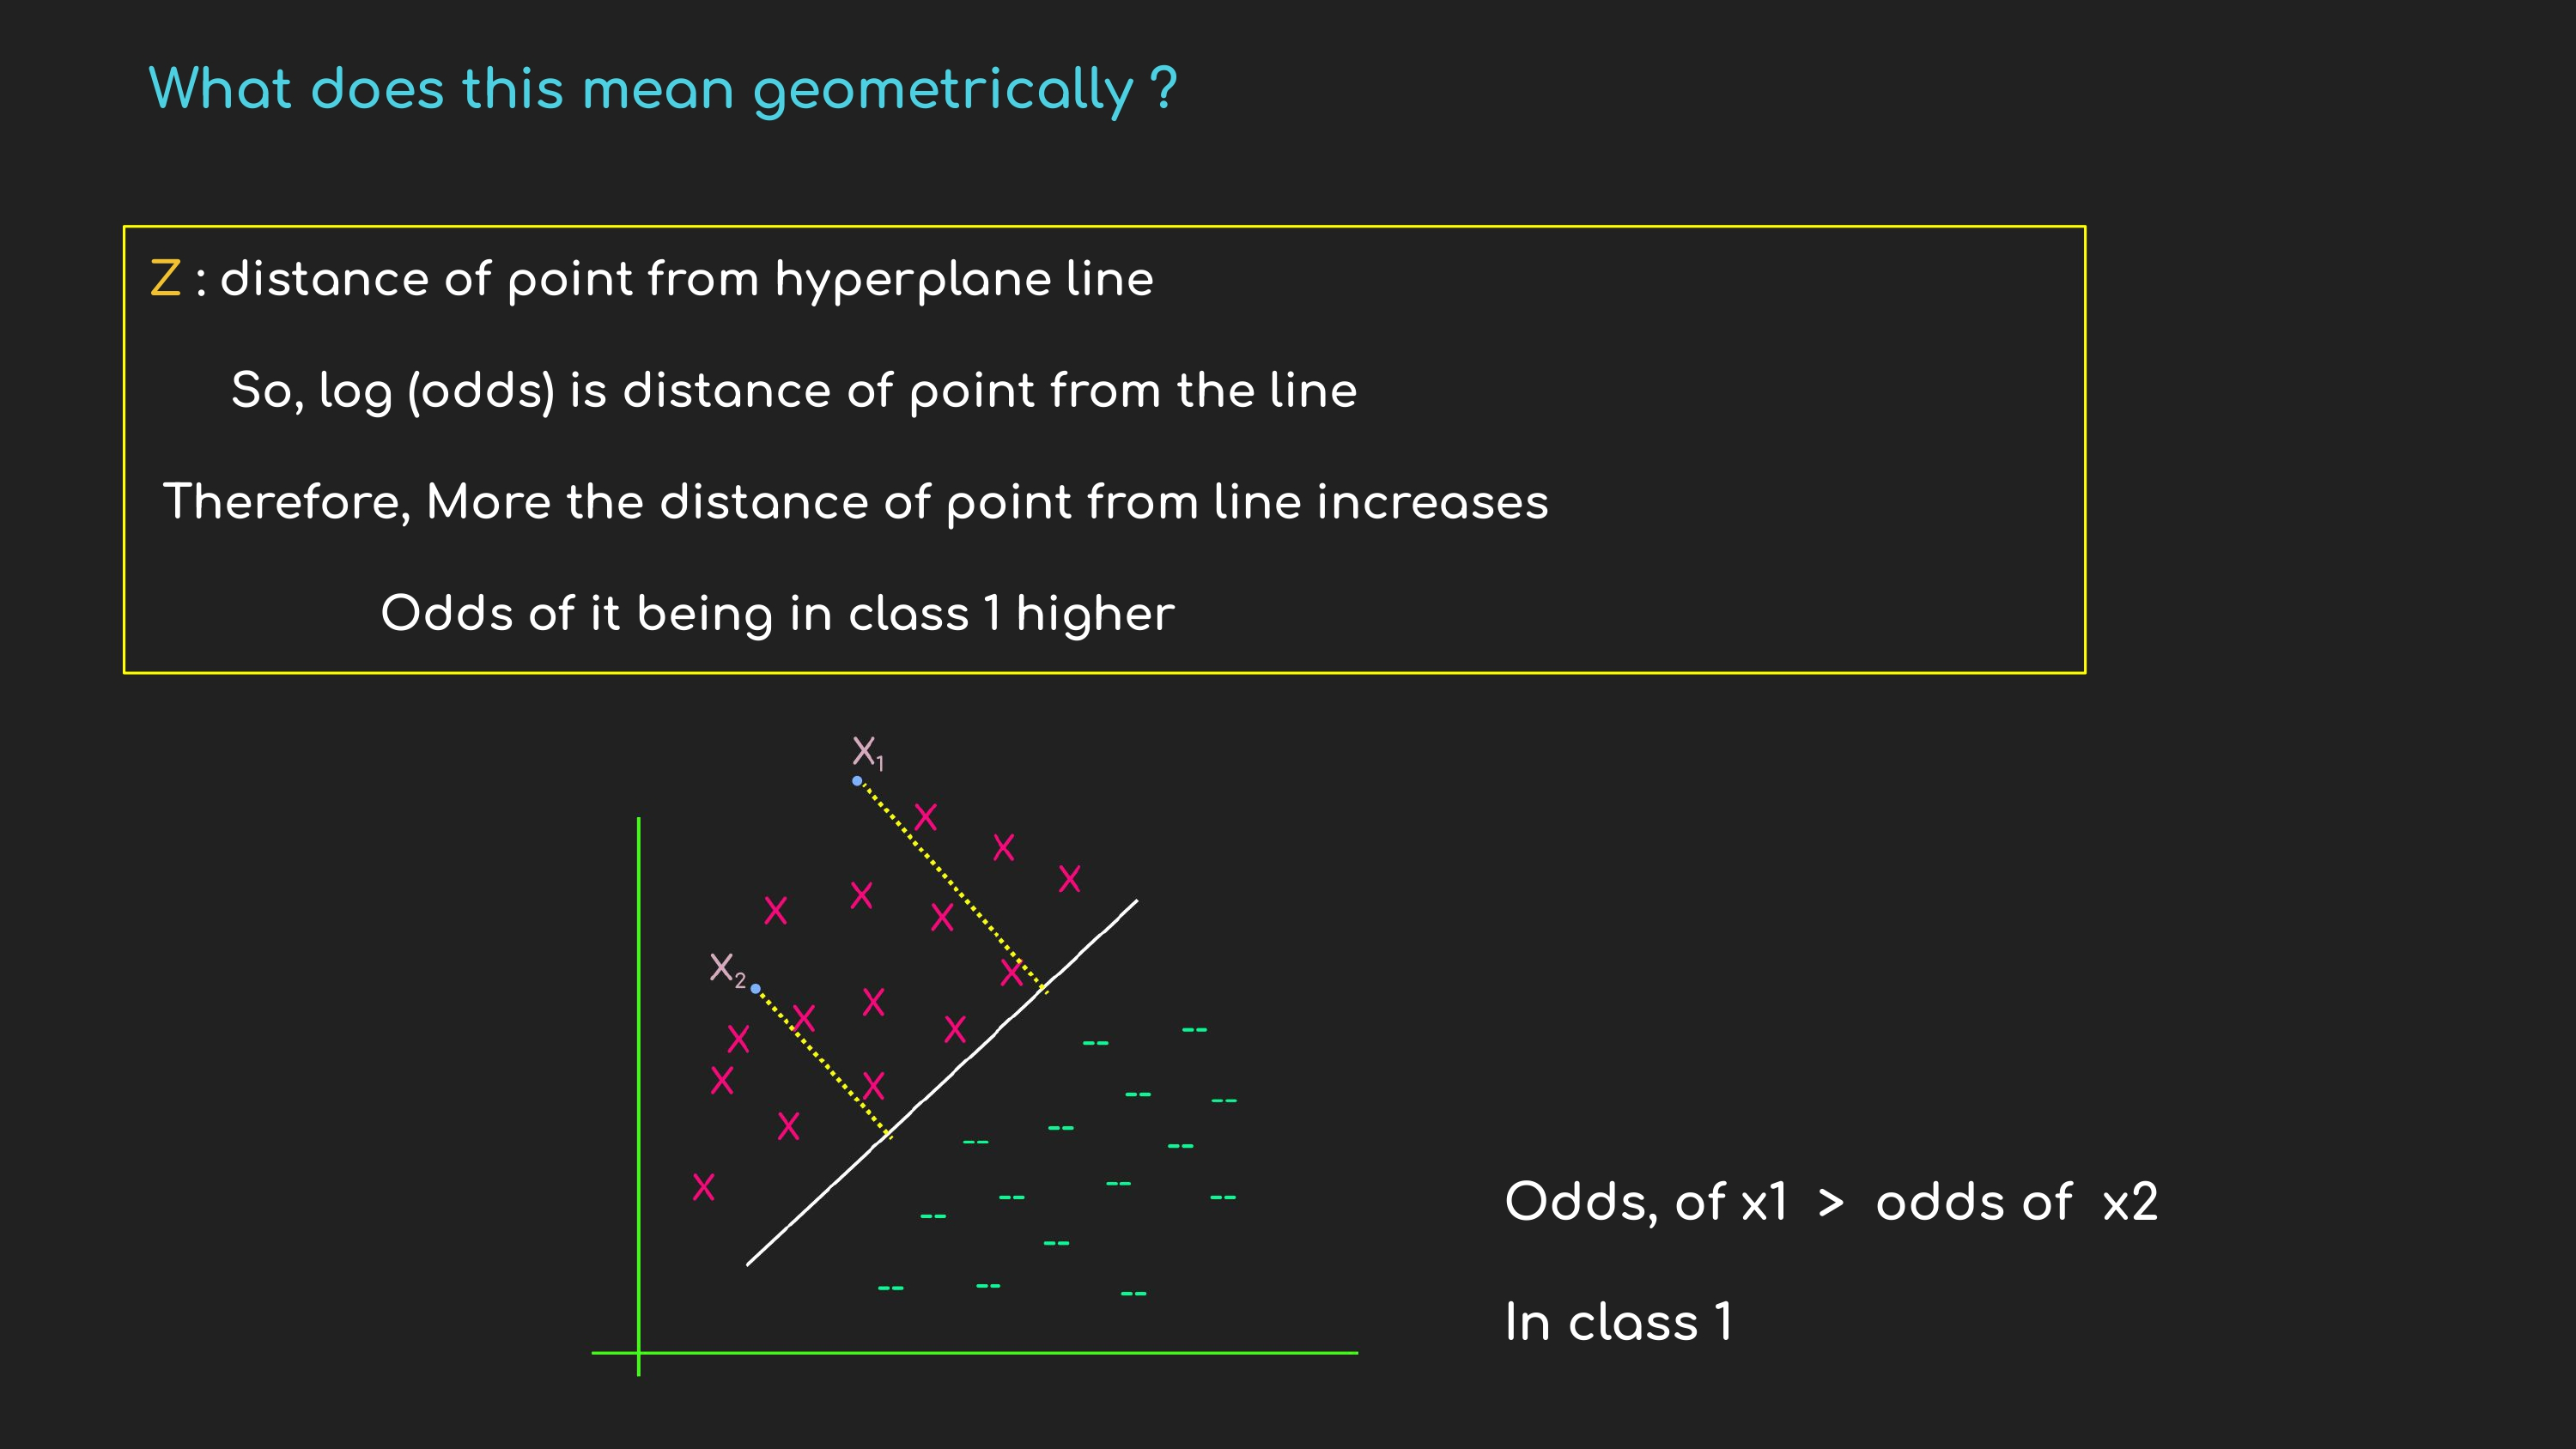